# Channel Estimation: Results Visualization

This notebook presents coded block error rate (BLER) plots to compare the channel estimation performance of agent-evolved solutions with that of the Sionna reference estimators.

Agent solutions must maintain torch.compile compliance.

## Imports

In [1]:
import os # Configure which GPU
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

import torch
import numpy as np
import pickle

import logging
logging.getLogger("torch._dynamo").setLevel(logging.ERROR)

import sionna.phy
sionna.phy.config.seed = 42

from sionna.phy import Block
from sionna.phy.ofdm import ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer, ResourceGrid, LMMSEInterpolator, RemoveNulledSubcarriers
from sionna.phy.channel.tr38901 import Antenna, AntennaArray, UMi, RMa
from sionna.phy.channel import OFDMChannel, gen_single_sector_topology, GenerateOFDMChannel
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.mapping import Mapper, BinarySource, Demapper
from sionna.phy.utils import ebnodb2no, sim_ber
from sionna.phy.mimo import StreamManagement

%matplotlib inline
import matplotlib.pyplot as plt

## Link configuration

In [ ]:
# System constants
NUM_UT = 4
NUM_TX_ANT = 1
NUM_RX_ANT = 16
NUM_BITS_PER_SYMBOL = 2
NUM_OFDM_SYMBOLS = 14
FFT_SIZE = 64
SUBCARRIER_SPACING = 30e3
CYCLIC_PREFIX_LENGTH = 0
NUM_GUARD_CARRIERS = [0, 0]
DC_NULL = False
PILOT_PATTERN = "kronecker"
PILOT_OFDM_SYMBOL_INDICES = [2, 11]
CODERATE = 0.5

# Carrier and channel parameters
CARRIER_FREQUENCY = 3.5e9

# Stream management for single TX with NUM_TX_ANT streams
SM = StreamManagement(np.ones([1, NUM_UT]), NUM_TX_ANT)

# Resource grid
RG = ResourceGrid(
    num_ofdm_symbols=NUM_OFDM_SYMBOLS,
    fft_size=FFT_SIZE,
    subcarrier_spacing=SUBCARRIER_SPACING,
    num_tx=NUM_UT,
    num_streams_per_tx=NUM_TX_ANT,
    cyclic_prefix_length=CYCLIC_PREFIX_LENGTH,
    num_guard_carriers=NUM_GUARD_CARRIERS,
    dc_null=DC_NULL,
    pilot_pattern=PILOT_PATTERN,
    pilot_ofdm_symbol_indices=PILOT_OFDM_SYMBOL_INDICES
)

# Derived constants
NUM_EFFECTIVE_SUBCARRIERS = RG.num_effective_subcarriers
NUM_DATA_SYMBOLS = RG.num_data_symbols

SPEED = 3 # m/s

def build_channel_model(channel_type):
    # Antenna arrays - 4 single-antenna UT, BS with 16 antennas
    ut_array = Antenna(
        polarization="single",
        polarization_type="V",
        antenna_pattern="omni",
        carrier_frequency=CARRIER_FREQUENCY
    )
    bs_array = AntennaArray(
        num_rows=1,
        num_cols=int(NUM_RX_ANT / 2),
        polarization="dual",
        polarization_type="cross",
        antenna_pattern="38.901",
        carrier_frequency=CARRIER_FREQUENCY
    )

    # Channel model
    if channel_type == "umi":
        channel_model = UMi(carrier_frequency=CARRIER_FREQUENCY,
                                    o2i_model='low',
                                    ut_array=ut_array,
                                    bs_array=bs_array,
                                    direction='uplink')
    elif channel_type == "rma":
        channel_model = RMa(carrier_frequency=CARRIER_FREQUENCY,
                                    ut_array=ut_array,
                                    bs_array=bs_array,
                                    direction='uplink')
    return channel_model

## Agent solutions

Below are the best solutions using GPT-OSS 120B and GPT 5.4 as LLM.

### GPT-OSS 120B

In [ ]:
import torch.nn.functional as F
class AgentEstimator_GPTOSS120B:

    def __init__(self):

        # ---------------------------------------------------------------------
        # Baseline components
        # ---------------------------------------------------------------------
        self._ls_est = LSChannelEstimator(RG, interpolation_type="lin_time_avg")

        # ---------------------------------------------------------------------
        # Hyper‑parameters (can be tuned later)
        # ---------------------------------------------------------------------
        self._SPARSE_TAPS = 4          # number of dominant taps kept in OMP sparsification
        self._MAX_TAPS = 16            # dictionary size for OMP (max channel length)
        self._FIR_KERNEL_LENGTH = 7    # odd length for symmetric FIR kernel
        # Low‑order spline kernel (cubic B‑spline approximation) for frequency smoothing
        self._FREQ_SPLINE_KERNEL = torch.tensor([0.125, 0.375, 0.5, 0.375, 0.125], dtype=torch.float32)

    # ---------------------------------------------------------------------
    # Helper functions
    # ---------------------------------------------------------------------
    def _build_dft_dictionary(self, fft_size: int, num_taps: int, device: torch.device = None, dtype=torch.complex64):
        """Build a DFT dictionary mapping ``num_taps`` time‑domain taps to ``fft_size``
        frequency‑domain samples.

        The dictionary ``A`` has shape ``[fft_size, num_taps]`` and satisfies
        ``h_freq = A @ h_time`` where ``h_time`` is a vector of length ``num_taps``.
        """
        if device is None:
            device = torch.device('cpu')
        n = torch.arange(fft_size, device=device, dtype=torch.float32)
        l = torch.arange(num_taps, device=device, dtype=torch.float32)
        exponent = -2j * torch.pi * n[:, None] * l[None, :] / fft_size
        A = torch.exp(exponent).type(dtype)
        return A


    def _omp(self, y: torch.Tensor, A: torch.Tensor, K: int) -> tuple[torch.Tensor, torch.Tensor]:
        """Simplified OMP that selects the ``K`` atoms with highest correlation in a
        single step and solves a least‑squares problem on the resulting support.

        Returns both the frequency‑domain channel estimate and an error‑variance
        estimate derived from the reconstruction residual.
        """
        N, M = y.shape  # N samples, M = fft_size
        L = A.shape[1]  # dictionary size (num_taps)
        device = y.device
        dtype = y.dtype

        # Correlation between observations and dictionary atoms (complex)
        corr = torch.matmul(y, torch.conj(A))  # shape: [N, L]
        mag = torch.abs(corr)
        # Select top‑K atoms per sample
        _, topk_idx = torch.topk(mag, K, dim=-1)  # shape: [N, K]
        # Gather selected columns from dictionary for each sample
        # A: [M, L] -> expand to [N, M, L]
        A_exp = A.unsqueeze(0).expand(N, -1, -1)  # (N, M, L)
        # topk_idx: [N, K] -> expand to (N, M, K) for gather
        idx_exp = topk_idx.unsqueeze(1).expand(-1, M, -1)  # (N, M, K)
        A_selected = torch.gather(A_exp, 2, idx_exp)  # (N, M, K)
        # Solve LS on selected atoms: y = A_selected @ x
        y_exp = y.unsqueeze(-1)  # (N, M, 1)
        # torch.linalg.lstsq works with complex numbers
        sol = torch.linalg.lstsq(A_selected, y_exp)
        x_est = sol.solution.squeeze(-1)  # (N, K)
        # Assemble full sparse vector of length L
        x_full = torch.zeros((N, L), dtype=dtype, device=device)
        rows = torch.arange(N, device=device).unsqueeze(1).expand(-1, K)
        x_full[rows, topk_idx] = x_est
        # Reconstruct frequency‑domain estimate
        h_hat = torch.matmul(A, x_full.T).T  # (N, M)
        # Residual for error variance
        residual = y - torch.matmul(A, x_full.T).T
        err = torch.abs(residual).type(torch.float32) ** 2
        return h_hat, err


    def _omp_channel_estimator(self, h_ls: torch.Tensor, K: int | None = None) -> tuple[torch.Tensor, torch.Tensor]:
        """Apply OMP sparsification to a LS channel estimate.

        The input ``h_ls`` has shape ``[..., num_ofdm_symbols, fft_size]`` (complex).
        Returns a sparse channel estimate and an error‑variance tensor with the same
        shape.
        """
        if K is None:
            K = self._SPARSE_TAPS
        fft_size = h_ls.shape[-1]
        # Build the DFT dictionary once (shared across all samples).
        A = self._build_dft_dictionary(fft_size, self._MAX_TAPS, device=h_ls.device, dtype=h_ls.dtype)
        # Collapse all leading dimensions (including OFDM‑symbol dimension) into one
        leading_shape = h_ls.shape[:-1]
        N = int(torch.prod(torch.tensor(leading_shape, device=h_ls.device)))
        y = h_ls.reshape(N, fft_size)
        h_hat_flat, err_flat = self._omp(y, A, K)
        h_hat = h_hat_flat.reshape(*leading_shape, fft_size)
        err = err_flat.reshape(*leading_shape, fft_size)
        return h_hat, err


    def _estimate_doppler_coeff(self, h):
        """Estimate a scalar Doppler correlation coefficient ``a`` from channel
        estimates across successive OFDM symbols.

        ``h`` is expected to have shape ``[..., T, F]`` where ``T`` is the time axis.
        The coefficient is clamped to the interval [0.5, 0.99] to avoid extreme
        values.
        """
        # Ensure there are at least two time samples
        if h.shape[-2] < 2:
            return 0.9  # fallback for degenerate case
        h_t = h[..., :-1, :]
        h_tp1 = h[..., 1:, :]
        eps = 1e-12
        num = torch.mean(torch.real(h_t * torch.conj(h_tp1)))
        den = torch.mean(torch.abs(h_t) ** 2) + eps
        a = num / den
        a = torch.clamp(a, 0.5, 0.99)  # keep within a reasonable range
        return a.item()


    def _fir_kernel_from_a(self, a: float, length: int) -> torch.Tensor:
        """Generate a symmetric FIR kernel of odd ``length`` based on the scalar
        Doppler coefficient ``a``. The kernel follows ``kernel[i] = a**abs(i)`` for
        offsets ``i`` from ``-half`` to ``half`` and is normalized to sum to one.
        """
        assert length % 2 == 1, "FIR kernel length must be odd"
        half = length // 2
        offsets = torch.arange(-half, half + 1, dtype=torch.float32)
        kernel = a ** torch.abs(offsets)
        kernel = kernel / kernel.sum()
        return kernel


    def _apply_fir_filter_complex(self, x: torch.Tensor, kernel: torch.Tensor) -> torch.Tensor:
        """Apply a 1‑D FIR filter (given by ``kernel``) across the time axis.

        Args:
            x: Complex tensor with shape [..., T, F].
            kernel: 1‑D real tensor (odd length) defining the FIR coefficients.
        Returns:
            y: Complex tensor of the same shape as ``x``.
        """
        real = x.real
        imag = x.imag
        *batch_dims, T, F_dim = real.shape
        # Collapse batch dimensions and frequency dimension into one dimension for conv1d
        N = int(torch.prod(torch.tensor(batch_dims + [F_dim])).item())
        real_flat = real.reshape(N, 1, T)
        imag_flat = imag.reshape(N, 1, T)
        k_len = kernel.numel()
        pad = (k_len // 2, k_len // 2)
        real_padded = F.pad(real_flat, pad, mode="replicate")
        imag_padded = F.pad(imag_flat, pad, mode="replicate")
        weight = kernel.view(1, 1, -1).to(real.dtype).to(real.device)
        real_filt = F.conv1d(real_padded, weight)
        imag_filt = F.conv1d(imag_padded, weight)
        real_filt = real_filt.reshape(*batch_dims, T, F_dim)
        imag_filt = imag_filt.reshape(*batch_dims, T, F_dim)
        return torch.complex(real_filt, imag_filt)


    def _apply_fir_filter_real(self, x: torch.Tensor, kernel: torch.Tensor) -> torch.Tensor:
        """Apply a 1‑D FIR filter across the time axis for real‑valued tensors.
        """
        *batch_dims, T, F_dim = x.shape
        N = int(torch.prod(torch.tensor(batch_dims + [F_dim])).item())
        flat = x.reshape(N, 1, T)
        k_len = kernel.numel()
        pad = (k_len // 2, k_len // 2)
        padded = F.pad(flat, pad, mode="replicate")
        weight = kernel.view(1, 1, -1).to(x.dtype).to(x.device)
        filt = F.conv1d(padded, weight)
        filt = filt.reshape(*batch_dims, T, F_dim)
        return filt


    def _apply_freq_spline_complex(self, x: torch.Tensor, kernel: torch.Tensor) -> torch.Tensor:
        """Smooth a complex‑valued tensor across the frequency axis using a spline kernel.
        """
        real = x.real
        imag = x.imag
        *batch_dims, T, F_dim = real.shape
        N = int(torch.prod(torch.tensor(batch_dims + [T])).item())
        real_flat = real.reshape(N, 1, F_dim)
        imag_flat = imag.reshape(N, 1, F_dim)
        k_len = kernel.numel()
        pad = (k_len // 2, k_len // 2)
        real_padded = F.pad(real_flat, pad, mode="replicate")
        imag_padded = F.pad(imag_flat, pad, mode="replicate")
        weight = kernel.view(1, 1, -1).to(real.dtype).to(real.device)
        real_smooth = F.conv1d(real_padded, weight)
        imag_smooth = F.conv1d(imag_padded, weight)
        real_smooth = real_smooth.reshape(*batch_dims, T, F_dim)
        imag_smooth = imag_smooth.reshape(*batch_dims, T, F_dim)
        return torch.complex(real_smooth, imag_smooth)


    def _apply_freq_spline_real(self, x: torch.Tensor, kernel: torch.Tensor) -> torch.Tensor:
        """Smooth a real‑valued tensor across the frequency axis using a spline kernel.
        """
        *batch_dims, T, F_dim = x.shape
        N = int(torch.prod(torch.tensor(batch_dims + [T])).item())
        flat = x.reshape(N, 1, F_dim)
        k_len = kernel.numel()
        pad = (k_len // 2, k_len // 2)
        padded = F.pad(flat, pad, mode="replicate")
        weight = kernel.view(1, 1, -1).to(x.dtype).to(x.device)
        smooth = F.conv1d(padded, weight)
        smooth = smooth.reshape(*batch_dims, T, F_dim)
        return smooth


    def _kalman_filter(self, h_ls: torch.Tensor, err_var: torch.Tensor,
                    h_meas_pilot: torch.Tensor, err_meas_pilot: torch.Tensor,
                    pilot_indices: list) -> tuple[torch.Tensor, torch.Tensor]:
        """Apply a per‑subcarrier Kalman filter across the OFDM‑symbol axis.

        Args:
            h_ls: LS channel estimate tensor of shape
                [B, N_rx, N_rx_ant, N_tx, N_stream, T, F] (complex).
            err_var: LS error‑variance tensor of the same shape (real).
            h_meas_pilot: OMP+FIR refined channel estimate at pilot symbols of shape
                [B, N_rx, N_rx_ant, N_tx, N_stream, P, F] (complex), where ``P`` is the
                number of pilot OFDM symbols.
            err_meas_pilot: Corresponding error‑variance tensor of shape
                [B, N_rx, N_rx_ant, N_tx, N_stream, P, F] (real).
            pilot_indices: List of OFDM‑symbol indices that contain pilots.

        Returns:
            h_filt: Kalman‑filtered channel estimate (complex) of shape same as ``h_ls``.
            err_filt: Corresponding error‑variance tensor (real) of same shape.
        """
        *batch_dims, T, F = h_ls.shape
        device = h_ls.device
        dtype = h_ls.dtype

        # Prepare output tensors
        h_filt = torch.empty_like(h_ls)
        err_filt = torch.empty_like(err_var)

        # Mapping from OFDM symbol index to pilot position index
        pilot_to_idx = {t: i for i, t in enumerate(pilot_indices)}

        # Initialise with the first OFDM symbol (use pilot measurement if available)
        if 0 in pilot_to_idx:
            idx0 = pilot_to_idx[0]
            h_prev = h_meas_pilot[..., idx0, :]
            P_prev = err_meas_pilot[..., idx0, :]
        else:
            h_prev = h_ls[..., 0, :]
            P_prev = err_var[..., 0, :]
        h_filt[..., 0, :] = h_prev
        err_filt[..., 0, :] = P_prev

        # AR(1) model parameters – we use a high correlation (close to 1) as a generic
        # prior. The exact value is not critical because the measurement updates dominate.
        a = torch.tensor(0.99, dtype=torch.float32, device=device)
        q = torch.tensor(1.0 - 0.99 * 0.99, dtype=torch.float32, device=device)

        for t in range(1, T):
            # Prediction step
            h_pred = a * h_prev
            P_pred = a * a * P_prev + q

            if t in pilot_to_idx:
                # Measurement update using refined pilot estimate
                idx = pilot_to_idx[t]
                z = h_meas_pilot[..., idx, :]
                R = err_meas_pilot[..., idx, :]
                # Kalman gain (real scalar per subcarrier)
                K_gain = P_pred / (P_pred + R)
                # Update step – K is real, broadcast over complex values
                h_upd = h_pred + K_gain * (z - h_pred)
                P_upd = (1.0 - K_gain) * P_pred
            else:
                # No measurement – keep prediction
                h_upd = h_pred
                P_upd = P_pred

            h_filt[..., t, :] = h_upd
            err_filt[..., t, :] = P_upd

            h_prev = h_upd
            P_prev = P_upd

        # Ensure non‑negative error variance
        err_filt = torch.clamp(err_filt, min=0.0)
        return h_filt, err_filt


    def _kalman_smoother(self, h_fwd: torch.Tensor, err_fwd: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Apply backward RTS smoothing to the forward‑filtered channel estimates.
        """
        *batch_dims, T, F = h_fwd.shape
        device = h_fwd.device
        a = torch.tensor(0.99, dtype=torch.float32, device=device)
        q = torch.tensor(1.0 - 0.99 * 0.99, dtype=torch.float32, device=device)

        h_smooth = torch.empty_like(h_fwd)
        err_smooth = torch.empty_like(err_fwd)

        # Initialise last time step
        h_smooth[..., -1, :] = h_fwd[..., -1, :]
        err_smooth[..., -1, :] = err_fwd[..., -1, :]

        # Backward pass
        for t in range(T - 2, -1, -1):
            # Forward filtered state at time t
            h_f_t = h_fwd[..., t, :]
            P_f_t = err_fwd[..., t, :]
            # Predicted state at time t+1 based on forward filtered at t
            h_pred = a * h_f_t
            P_pred = a * a * P_f_t + q
            # Smoothing gain (real)
            C = P_f_t * a / P_pred
            # Next smoothed state (already computed)
            h_s_next = h_smooth[..., t + 1, :]
            P_s_next = err_smooth[..., t + 1, :]
            # Rauch‑Tung‑Striebel update
            h_smooth[..., t, :] = h_f_t + C * (h_s_next - h_pred)
            err_smooth[..., t, :] = P_f_t + C * C * (P_s_next - P_pred)

        err_smooth = torch.clamp(err_smooth, min=0.0)
        return h_smooth, err_smooth

    # ---------------------------------------------------------------------
    # MIMO detector implementation following the assigned approach.
    # ---------------------------------------------------------------------
    def __call__(self, y: torch.Tensor, no: torch.Tensor):
        """MIMO detector with adaptive multi‑tap FIR channel tracking, OMP‑Kalman
        refinement, and spline frequency smoothing.

        Args:
            y: Received resource‑grid tensor of shape
            [batch, num_rx, num_rx_ant, num_ofdm_symbols, fft_size] (complex64).
            no: Noise variance (scalar or broadcastable to the batch dimensions).

        Returns:
            llr: Log‑likelihood ratios of shape
                [batch, NUM_UT, NUM_TX_ANT, NUM_DATA_SYMBOLS * NUM_BITS_PER_SYMBOL] (float32).
        """
        # 1. LS channel estimate (provides full‑band estimate and error variance)
        h_ls, err_ls = self._ls_est(y, no)

        # 2. Extract pilot OFDM‑symbol indices from the resource grid configuration.
        pilot_indices = getattr(RG, 'pilot_ofdm_symbol_indices', None)
        if pilot_indices is None:
            pilot_indices = getattr(RG, '_pilot_ofdm_symbol_indices', [])
        if not isinstance(pilot_indices, (list, tuple)):
            pilot_indices = list(pilot_indices)

        if len(pilot_indices) == 0:
            # No pilots – fall back to LS estimate only (unlikely in realistic configs)
            h_refined = h_ls
            err_refined = err_ls
        else:
            # 3. Apply OMP sparsification on pilot symbols only
            h_ls_pilot = h_ls[..., pilot_indices, :]
            err_ls_pilot = err_ls[..., pilot_indices, :]
            h_omp_pilot, err_omp_pilot = self._omp_channel_estimator(h_ls_pilot, K=self._SPARSE_TAPS)

            # 4. Estimate Doppler correlation coefficient from the OMP pilot estimates
            a_est = self._estimate_doppler_coeff(h_omp_pilot)

            # 5. Build an adaptive symmetric FIR kernel based on the estimated ``a``.
            kernel_time = self._fir_kernel_from_a(a_est, self._FIR_KERNEL_LENGTH).to(h_omp_pilot.device).to(h_omp_pilot.dtype)

            # 6. Apply the FIR filter across the pilot (time) axis to both channel
            #    estimate and error‑variance tensors.
            h_omp_fir = self._apply_fir_filter_complex(h_omp_pilot, kernel_time)
            err_omp_fir = self._apply_fir_filter_real(err_omp_pilot, kernel_time)

            # 7. Kalman filter across all OFDM symbols, using the FIR‑filtered OMP
            #    estimates at pilot positions.
            h_fwd, err_fwd = self._kalman_filter(h_ls, err_ls,
                                            h_omp_fir, err_omp_fir,
                                            pilot_indices)
            # 8. Backward RTS smoothing
            h_smooth, err_smooth = self._kalman_smoother(h_fwd, err_fwd)

            # 9. Apply the FIR filter across the full time axis to the OMP‑Kalman estimate
            h_fir = self._apply_fir_filter_complex(h_smooth, kernel_time)
            err_fir = self._apply_fir_filter_real(err_smooth, kernel_time)
            err_fir = torch.clamp(err_fir, min=0.0)

            # 10. Low‑order spline smoothing across the frequency axis
            kernel_freq = self._FREQ_SPLINE_KERNEL.to(h_fir.device).to(h_fir.dtype)
            kernel_freq = kernel_freq / kernel_freq.sum()
            h_refined = self._apply_freq_spline_complex(h_fir, kernel_freq)
            err_refined = self._apply_freq_spline_real(err_fir, kernel_freq)

        return h_refined, err_refined

### GPT 5.4

In [ ]:
class AgentEstimator_GPT54:

    def __init__(self):

        self._ls_est = LSChannelEstimator(RG, interpolation_type="lin_time_avg")
        self._CACHE = {}


    def _get_cache(self, device):
        key = str(device)
        if key in self._CACHE:
            return self._CACHE[key]

        pp = RG.pilot_pattern
        mask = torch.as_tensor(pp.mask, device=device).bool()
        pilots = torch.as_tensor(pp.pilots, device=device)
        num_tx, num_st, num_sym, num_eff = mask.shape

        pilot_vals = torch.zeros((num_tx, num_st, num_sym, num_eff), dtype=pilots.dtype, device=device)
        for tx in range(num_tx):
            for st in range(num_st):
                pilot_vals[tx, st][mask[tx, st]] = pilots[tx, st]

        coords_t = torch.arange(num_sym, device=device, dtype=torch.float32).view(1, 1, num_sym, 1)
        coords_f = torch.arange(num_eff, device=device, dtype=torch.float32).view(1, 1, 1, num_eff)

        pilot_t = torch.where(mask, coords_t.expand_as(mask), torch.full_like(coords_t.expand_as(mask), -1.0))
        left_t = torch.cummax(pilot_t, dim=-2).values
        right_t = torch.flip(torch.cummin(torch.flip(torch.where(mask, coords_t.expand_as(mask), torch.full_like(coords_t.expand_as(mask), float(num_sym))), dims=[-2]), dim=-2).values, dims=[-2])
        dt_left = torch.where(left_t >= 0.0, coords_t - left_t, torch.full_like(coords_t, 1e6))
        dt_right = torch.where(right_t < float(num_sym), right_t - coords_t, torch.full_like(coords_t, 1e6))
        nearest_t = (dt_left <= dt_right).to(torch.float32) * left_t + (dt_left > dt_right).to(torch.float32) * right_t
        nearest_t = torch.where((dt_left < 1e6) | (dt_right < 1e6), nearest_t, coords_t)
        nearest_t_idx = nearest_t.long().clamp(0, num_sym - 1)
        dist_t = torch.minimum(dt_left, dt_right).clamp_max(float(num_sym)).to(torch.float32)

        pilot_f = torch.where(mask, coords_f.expand_as(mask), torch.full_like(coords_f.expand_as(mask), -1.0))
        left_f = torch.cummax(pilot_f, dim=-1).values
        right_f = torch.flip(torch.cummin(torch.flip(torch.where(mask, coords_f.expand_as(mask), torch.full_like(coords_f.expand_as(mask), float(num_eff))), dims=[-1]), dim=-1).values, dims=[-1])
        df_left = torch.where(left_f >= 0.0, coords_f - left_f, torch.full_like(coords_f, 1e6))
        df_right = torch.where(right_f < float(num_eff), right_f - coords_f, torch.full_like(coords_f, 1e6))
        nearest_f = (df_left <= df_right).to(torch.float32) * left_f + (df_left > df_right).to(torch.float32) * right_f
        nearest_f = torch.where((df_left < 1e6) | (df_right < 1e6), nearest_f, coords_f)
        nearest_f_idx = nearest_f.long().clamp(0, num_eff - 1)
        dist_f = torch.minimum(df_left, df_right).clamp_max(float(num_eff)).to(torch.float32)

        support = mask.to(torch.float32)
        for _ in range(2):
            support = 0.30 * support \
                    + 0.27 * torch.cat([support[..., :1], support[..., :-1]], dim=-1) \
                    + 0.27 * torch.cat([support[..., 1:], support[..., -1:]], dim=-1) \
                    + 0.08 * torch.cat([support[..., :1, :], support[..., :-1, :]], dim=-2) \
                    + 0.08 * torch.cat([support[..., 1:, :], support[..., -1:, :]], dim=-2)

        dscore = dist_f + 1.55 * dist_t
        near_region = (~mask) & (dscore <= 1.7)
        far_region = (~mask) & (dscore > 3.55)
        mid_region = (~mask) & (~near_region) & (~far_region)

        self._CACHE[key] = {
            "mask": mask,
            "pilot_vals": pilot_vals,
            "nearest_t_idx": nearest_t_idx,
            "nearest_f_idx": nearest_f_idx,
            "support": support.clamp_min(1e-3),
            "dist_t": dist_t,
            "dist_f": dist_f,
            "dscore": dscore,
            "near_region": near_region,
            "mid_region": mid_region,
            "far_region": far_region,
        }
        return self._CACHE[key]


    def _init_from_pilots(self, h0, pilot_mask):
        c = self._get_cache(h0.device)
        idx_t = c["nearest_t_idx"][None, None, None, ...].expand(h0.shape[0], h0.shape[1], h0.shape[2], -1, -1, -1, -1)
        idx_f = c["nearest_f_idx"][None, None, None, ...].expand(h0.shape[0], h0.shape[1], h0.shape[2], -1, -1, -1, -1)

        ht = torch.gather(h0, -2, idx_t)
        hf = torch.gather(h0, -1, idx_f)
        h = torch.where(pilot_mask, h0, 0.66 * hf + 0.34 * ht)

        for _ in range(2):
            left = torch.cat([h[..., :1], h[..., :-1]], dim=-1)
            right = torch.cat([h[..., 1:], h[..., -1:]], dim=-1)
            up = torch.cat([h[..., :1, :], h[..., :-1, :]], dim=-2)
            down = torch.cat([h[..., 1:, :], h[..., -1:, :]], dim=-2)
            avg = 0.28 * h + 0.31 * left + 0.31 * right + 0.05 * up + 0.05 * down
            h = torch.where(pilot_mask, h0, avg)
        return h


    def _phase_mismatch(self, a, b):
        corr = a * torch.conj(b)
        phase = corr / torch.clamp(torch.abs(corr), min=1e-4)
        return (torch.abs(a - phase * b) / (0.5 * (torch.abs(a) + torch.abs(b)).clamp_min(2e-3))).to(torch.float32)


    def _estimate_graph(self, y, no):
        h0, e0 = self._ls_est(y, no)
        cache = self._get_cache(y.device)
        pilot_mask = cache["mask"][None, None, None, ...]
        support = cache["support"][None, None, None, ...]

        h = self._init_from_pilots(h0, pilot_mask)
        h_prev = h.clone()
        pilot_obs = torch.where(pilot_mask, h0, torch.zeros_like(h0))

        pair_t = pilot_mask[..., 1:, :] & pilot_mask[..., :-1, :]
        pair_f = pilot_mask[..., :, 1:] & pilot_mask[..., :, :-1]

        pd_t = self._phase_mismatch(h0[..., 1:, :], h0[..., :-1, :])
        pd_f = self._phase_mismatch(h0[..., :, 1:], h0[..., :, :-1])
        pd_t = torch.where(pair_t, pd_t, torch.zeros_like(pd_t))
        pd_f = torch.where(pair_f, pd_f, torch.zeros_like(pd_f))

        gate_t = torch.clamp(1.0 - 0.08 * pd_t, 0.92, 0.985)
        gate_f = torch.clamp(1.0 - 0.14 * pd_f, 0.94, 0.997)

        no_b = torch.as_tensor(no, device=y.device, dtype=torch.float32)
        while no_b.ndim < 7:
            no_b = no_b.unsqueeze(-1)
        obs_w = pilot_mask.to(torch.float32) * torch.clamp(0.16 + 0.56 / no_b.clamp_min(1e-4), max=8.0)

        alpha_t = 0.055
        alpha_f = 1.235

        for it in range(7):
            left = torch.cat([h[..., :1], h[..., :-1]], dim=-1)
            right = torch.cat([h[..., 1:], h[..., -1:]], dim=-1)
            up = torch.cat([h[..., :1, :], h[..., :-1, :]], dim=-2)
            down = torch.cat([h[..., 1:, :], h[..., -1:, :]], dim=-2)

            wf_l = alpha_f * torch.cat([gate_f[..., :1] * 0.0, gate_f], dim=-1)
            wf_r = alpha_f * torch.cat([gate_f, gate_f[..., -1:] * 0.0], dim=-1)
            wt_u = alpha_t * torch.cat([gate_t[..., :1, :] * 0.0, gate_t], dim=-2)
            wt_d = alpha_t * torch.cat([gate_t, gate_t[..., -1:, :] * 0.0], dim=-2)

            num = obs_w * pilot_obs + wf_l * left + wf_r * right + wt_u * up + wt_d * down
            den = obs_w + wf_l + wf_r + wt_u + wt_d + 1e-6
            h_new = num / den
            blend = 0.972 if it < 5 else 0.982
            h_prev, h = h, torch.where(pilot_mask, h0, blend * h_new + (1.0 - blend) * h)

        left = torch.cat([h[..., :1], h[..., :-1]], dim=-1)
        right = torch.cat([h[..., 1:], h[..., -1:]], dim=-1)
        h_freq = 0.16 * h + 0.42 * left + 0.42 * right
        h = torch.where(pilot_mask, h0, h_freq)
        h = torch.where(pilot_mask, h0, h)

        pilot_resid = (torch.abs((h - h0) * pilot_mask) ** 2).to(torch.float32)
        pilot_cnt = pilot_mask.to(torch.float32).sum(dim=(-1, -2), keepdim=True).clamp_min(1.0)
        pilot_mse = pilot_resid.sum(dim=(-1, -2), keepdim=True) / pilot_cnt

        dscore = cache["dscore"][None, None, None, ...]
        near_region = cache["near_region"][None, None, None, ...]
        mid_region = cache["mid_region"][None, None, None, ...]
        far_region = cache["far_region"][None, None, None, ...]

        diff_mag = (torch.abs(h - h_prev) / torch.clamp(torch.abs(h), min=3e-3)).to(torch.float32)
        conf = torch.clamp(diff_mag, 0.0, 0.5)

        support_inv = 1.0 / support.clamp_min(0.28)
        support_excess = (support_inv - 1.0).clamp_min(0.0)
        pilot_quality = torch.clamp(pilot_mse / (0.25 * e0.mean(dim=(-1, -2), keepdim=True) + 1e-4), 0.0, 4.0)

        dist_term_near = 0.0013 + 0.0028 * dscore + 0.0018 * support_excess
        dist_term_mid = 0.0048 + 0.0055 * dscore + 0.0042 * support_excess
        dist_term_far = 0.0092 + 0.0080 * dscore + 0.0070 * support_excess + 0.0038 * pilot_quality

        err_pilot = torch.clamp(0.26 * e0 + 0.006 * no_b, min=1e-4)
        err_near = 0.070 * e0 + 0.060 * pilot_mse + dist_term_near + 0.0095 * conf
        err_mid = 0.092 * e0 + 0.235 * pilot_mse + dist_term_mid + 0.0160 * conf
        err_far = 0.125 * e0 + 0.545 * pilot_mse + dist_term_far + 0.0240 * conf

        err_var = err_pilot
        err_var = torch.where(near_region, err_near.to(torch.float32), err_var)
        err_var = torch.where(mid_region, err_mid.to(torch.float32), err_var)
        err_var = torch.where(far_region, err_far.to(torch.float32), err_var)
        err_var = torch.clamp(err_var.to(torch.float32), min=1e-4)
        return h, err_var


    def __call__(self, y, no):
        h_hat, err_var = self._estimate_graph(y, no)
        return h_hat, err_var

## Evaluation E2E model

In [ ]:
class MIMOModel(Block):
    """MIMO OFDM transmission model with UMi or RMa channel for detector evaluation.

    This model simulates a 4x16 MIMO uplink transmission using:
    - 4 TX antennas (UT) and 16 RX antennas (BS)
    - UMi channel model (good for spatial multiplexing)
    - 5G NR LDPC coding with rate 0.5
    - QPSK modulation
    - Custom channel estimator
    """

    def __init__(self, estimator, channel_type, perfect_csi=False):
        super().__init__()

        # Store detector function
        self._estimator = estimator

        # Use imported configuration
        self._num_ut = NUM_UT
        self._num_tx_ant = NUM_TX_ANT
        self._num_rx_ant = NUM_RX_ANT
        self._num_streams_per_tx = NUM_TX_ANT
        self._num_ofdm_symbols = NUM_OFDM_SYMBOLS
        self._num_bits_per_symbol = NUM_BITS_PER_SYMBOL
        self._coderate = CODERATE
        self._channel_type = channel_type
        self._perfect_csi = perfect_csi

        # Use imported resource grid and stream management
        self._rg = RG
        self._sm = SM

        # Coding parameters
        self._n = int(self._rg.num_data_symbols * self._num_bits_per_symbol)
        self._k = int(self._n * self._coderate)

        self._channel_model = build_channel_model(channel_type)

        # Channel application
        self._channel = OFDMChannel(self._channel_model, self._rg, return_channel=self._perfect_csi,
                                    normalize_channel=True)

        # Transmitter components
        self._binary_source = BinarySource()
        self._encoder = LDPC5GEncoder(self._k, self._n)
        self._mapper = Mapper("qam", self._num_bits_per_symbol)
        self._rg_mapper = ResourceGridMapper(self._rg)

        # Receiver
        if self._perfect_csi:
            self._remove_nulled_subcarriers = RemoveNulledSubcarriers(self._rg)
        self._equalizer = LMMSEEqualizer(self._rg, self._sm)
        self._demapper = Demapper("app", "qam", NUM_BITS_PER_SYMBOL)
        self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)

    @torch.compile
    def call(self, batch_size, ebno_db):
        # Compute noise power
        no = ebnodb2no(ebno_db, self._num_bits_per_symbol, self._coderate, self._rg)

        # Transmitter
        b = self._binary_source([batch_size, self._num_ut, self._num_streams_per_tx, self._k])
        c = self._encoder(b)
        x = self._mapper(c)
        x_rg = self._rg_mapper(x)

        # Channel - generate CIR and convert to frequency domain
        topology = gen_single_sector_topology(batch_size, self._num_ut, self._channel_type, max_ut_velocity=SPEED)
        self._channel_model.set_topology(*topology)

        # Apply channel
        if self._perfect_csi:
            y, h = self._channel(x_rg, no)
        else:
            y = self._channel(x_rg, no)

        # Decoding
        if self._perfect_csi:
            h_hat, err_var = self._remove_nulled_subcarriers(h), 0.0
        else:
            h_hat, err_var = self._estimator(y, no)
        x_hat, no_eff = self._equalizer(y, h_hat, err_var, no)
        llr = self._demapper(x_hat, no_eff)

        # Reshape LLRs if needed to match expected shape [batch, 1, num_streams, n]
        llr = torch.reshape(llr, [batch_size, self._num_ut, self._num_streams_per_tx, self._n])

        b_hat = self._decoder(llr)

        return b, b_hat

## Evaluations

In [ ]:
BATCH_SIZE = 100
MAX_MC_ITER = 1000
NUM_TARGET_BLOCK_ERRORS = 1000
TARGET_BLER = 1e-3

SNR_RANGE_UMI = (-10.0, 5.0, 1.0)
snr_points_umi = np.arange(SNR_RANGE_UMI[0], SNR_RANGE_UMI[1] + 0.5, SNR_RANGE_UMI[2])

SNR_RANGE_RMA = (-10.0, 5.0, 1.0)
snr_points_rma = np.arange(SNR_RANGE_RMA[0], SNR_RANGE_RMA[1] + 0.5, SNR_RANGE_RMA[2])

In [ ]:
BLER = {"umi": {}, "rma": {}}

In [ ]:
# Load preexisting bler data
try:
    with open("bler.pkl", "rb") as f:
        BLER = pickle.load(f)
except FileNotFoundError:
    print("No preexisting bler data found")

### Baseline

#### Perfect CSI

In [ ]:
# UMi
model = MIMOModel(None, "umi", perfect_csi=True)
_, bler_baseline = sim_ber(model, snr_points_umi, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_baseline = bler_baseline.cpu().numpy()
BLER["umi"]["perfect-csi"] = (snr_points_umi, bler_baseline)
del bler_baseline

# RMa
model = MIMOModel(None, "rma", perfect_csi=True)
_, bler_baseline = sim_ber(model, snr_points_rma, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_baseline = bler_baseline.cpu().numpy()
BLER["rma"]["perfect-csi"] = (snr_points_rma, bler_baseline)
del bler_baseline

In [ ]:
# Save as pickle
with open("bler.pkl", "wb") as f:
    pickle.dump(BLER, f)

#### LS + Linear interpolation with time averaging

In [ ]:
# UMi
model = MIMOModel(LSChannelEstimator(RG, interpolation_type="lin_time_avg"), "umi")
_, bler_baseline = sim_ber(model, snr_points_umi, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_baseline = bler_baseline.cpu().numpy()
BLER["umi"]["baseline"] = (snr_points_umi, bler_baseline)
del bler_baseline

# RMa
model = MIMOModel(LSChannelEstimator(RG, interpolation_type="lin_time_avg"), "rma")
_, bler_baseline = sim_ber(model, snr_points_rma, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_baseline = bler_baseline.cpu().numpy()
BLER["rma"]["baseline"] = (snr_points_rma, bler_baseline)
del bler_baseline

In [ ]:
# Save as pickle
with open("bler.pkl", "wb") as f:
    pickle.dump(BLER, f)

#### LMMSE interpolation

Compute the covariance matrices

In [ ]:
def estimate_covariance_matrices(num_it, batch_size, channel_type):

    channel_model = build_channel_model(channel_type)
    channel_sampler = GenerateOFDMChannel(channel_model, RG, normalize_channel=True)

    @torch.compile
    def _estimate_covariance_matrices():

        freq_cov_mat = torch.zeros([FFT_SIZE, FFT_SIZE], dtype=torch.complex64, device=sionna.phy.config.device)
        time_cov_mat = torch.zeros([NUM_OFDM_SYMBOLS, NUM_OFDM_SYMBOLS], dtype=torch.complex64, device=sionna.phy.config.device)
        space_cov_mat = torch.zeros([NUM_RX_ANT, NUM_RX_ANT], dtype=torch.complex64, device=sionna.phy.config.device)
        for _ in range(num_it):
            # [batch size, num_rx_ant, num_ofdm_symbols, fft_size]
            # Sample random topologies
            topology = gen_single_sector_topology(batch_size, 1, channel_type, max_ut_velocity=SPEED)
            channel_model.set_topology(*topology)

            # Sample channel frequency responses
            # [batch size, 1, num_rx_ant, 1, 1, num_ofdm_symbols, fft_size]
            h_freq = channel_sampler(batch_size)
            # [batch size, num_rx_ant, num_ofdm_symbols, fft_size]
            h_freq = h_freq[:,0,:,0,0]

            #################################
            # Estimate frequency covariance
            #################################
            # [batch size, num_rx_ant, fft_size, num_ofdm_symbols]
            h_samples_ = h_freq.permute(0, 1, 3, 2)
            # [batch size, num_rx_ant, fft_size, fft_size]
            freq_cov_mat_ = torch.matmul(h_samples_, h_samples_.conj().transpose(-2, -1))
            # [fft_size, fft_size]
            freq_cov_mat_ = freq_cov_mat_.mean(dim=(0, 1))
            # [fft_size, fft_size]
            freq_cov_mat += freq_cov_mat_

            ################################
            # Estimate time covariance
            ################################
            # [batch size, num_rx_ant, num_ofdm_symbols, fft_size]
            time_cov_mat_ = torch.matmul(h_freq, h_freq.conj().transpose(-2, -1))
            # [num_ofdm_symbols, num_ofdm_symbols]
            time_cov_mat_ = time_cov_mat_.mean(dim=(0, 1))
            # [num_ofdm_symbols, num_ofdm_symbols]
            time_cov_mat += time_cov_mat_

            ###############################
            # Estimate spatial covariance
            ###############################
            # [batch size, num_ofdm_symbols, num_rx_ant, fft_size]
            h_samples_ = h_freq.permute(0, 2, 1, 3)
            # [batch size, num_ofdm_symbols, num_rx_ant, num_rx_ant]
            space_cov_mat_ = torch.matmul(h_samples_, h_samples_.conj().transpose(-2, -1))
            # [num_rx_ant, num_rx_ant]
            space_cov_mat_ = space_cov_mat_.mean(dim=(0, 1))
            # [num_rx_ant, num_rx_ant]
            space_cov_mat += space_cov_mat_

        freq_cov_mat /= NUM_OFDM_SYMBOLS * num_it
        time_cov_mat /= FFT_SIZE * num_it
        space_cov_mat /= FFT_SIZE * num_it
        return freq_cov_mat, time_cov_mat, space_cov_mat

    return _estimate_covariance_matrices()

In [ ]:
batch_size = 1000
num_iterations = 100
freq_cov_mat_umi, time_cov_mat_umi, space_cov_mat_umi = estimate_covariance_matrices(num_iterations, batch_size, "umi")
freq_cov_mat_rma, time_cov_mat_rma, space_cov_mat_rma = estimate_covariance_matrices(num_iterations, batch_size, "rma")

with open("channel_cov.pkl", "wb") as f:
    pickle.dump({"umi": {"freq": freq_cov_mat_umi, "time": time_cov_mat_umi, "space": space_cov_mat_umi},
                "rma": {"freq": freq_cov_mat_rma, "time": time_cov_mat_rma, "space": space_cov_mat_rma}}, f)

In [ ]:
# Load channel covariance matrices
with open("channel_cov.pkl", "rb") as f:
    channel_cov = pickle.load(f)
freq_cov_mat_umi = channel_cov["umi"]["freq"]
time_cov_mat_umi = channel_cov["umi"]["time"]
space_cov_mat_umi = channel_cov["umi"]["space"]
freq_cov_mat_rma = channel_cov["rma"]["freq"]
time_cov_mat_rma = channel_cov["rma"]["time"]
space_cov_mat_rma = channel_cov["rma"]["space"]

In [ ]:
# UMi
lmmse_int = LMMSEInterpolator(RG.pilot_pattern, time_cov_mat_umi, freq_cov_mat_umi, space_cov_mat_umi, order="t-f-s")
model = MIMOModel(LSChannelEstimator(RG, interpolator=lmmse_int), "umi")
_, bler_baseline = sim_ber(model, snr_points_umi, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_baseline = bler_baseline.cpu().numpy()
BLER["umi"]["baseline-lmmse"] = (snr_points_umi, bler_baseline)
del bler_baseline, model, lmmse_int

# RMa
lmmse_int = LMMSEInterpolator(RG.pilot_pattern, time_cov_mat_rma, freq_cov_mat_rma, space_cov_mat_rma, order="t-f-s")
model = MIMOModel(LSChannelEstimator(RG, interpolator=lmmse_int), "rma")
_, bler_baseline = sim_ber(model, snr_points_rma, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_baseline = bler_baseline.cpu().numpy()
BLER["rma"]["baseline-lmmse"] = (snr_points_rma, bler_baseline)
del bler_baseline, model, lmmse_int

In [ ]:
# Save as pickle
with open("bler.pkl", "wb") as f:
    pickle.dump(BLER, f)

### Agent solution

In [ ]:
#### GPT-OSS 120B

# UMi
model = MIMOModel(AgentEstimator_GPTOSS120B(), "umi")
_, bler_agent = sim_ber(model, snr_points_umi, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_agent = bler_agent.cpu().numpy()
BLER["umi"]["agent-gpt-oss-120b"] = (snr_points_umi, bler_agent)
del bler_agent, model

# RMa
model = MIMOModel(AgentEstimator_GPTOSS120B(), channel_type="rma")
_, bler_agent = sim_ber(model, snr_points_rma, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_agent = bler_agent.cpu().numpy()
BLER["rma"]["agent-gpt-oss-120b"] = (snr_points_rma, bler_agent)
del bler_agent, model

#### GPT 5.4

# UMi
model = MIMOModel(AgentEstimator_GPT54(), "umi")
_, bler_agent = sim_ber(model, snr_points_umi, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_agent = bler_agent.cpu().numpy()
BLER["umi"]["agent-gpt-5.4"] = (snr_points_umi, bler_agent)
del bler_agent, model

# RMa
model = MIMOModel(AgentEstimator_GPT54(), channel_type="rma")
_, bler_agent = sim_ber(model, snr_points_rma, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_agent = bler_agent.cpu().numpy()
BLER["rma"]["agent-gpt-5.4"] = (snr_points_rma, bler_agent)
del bler_agent, model

In [ ]:
# Save as pickle
with open("bler.pkl", "wb") as f:
    pickle.dump(BLER, f)

## Visualization

In [2]:
# Load the BLER data
with open("bler.pkl", "rb") as f:
    BLER = pickle.load(f)

Text(0.5, 1.0, 'UMi channel')

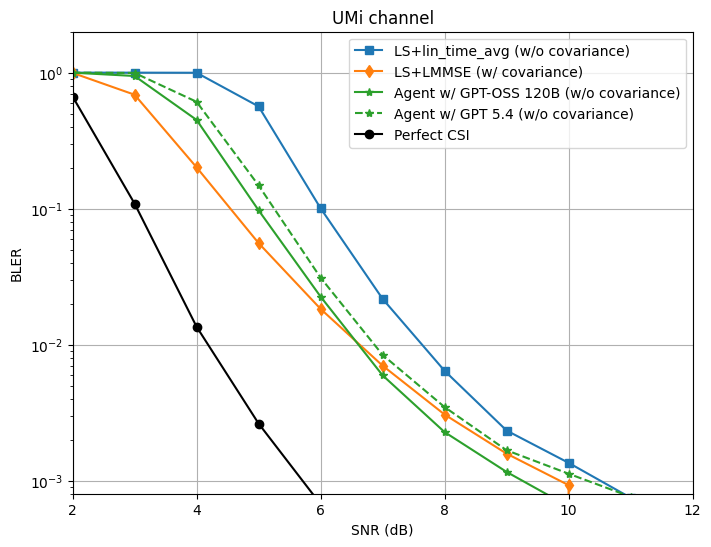

In [3]:
bler_ = BLER["umi"]

# Plot the BLER curves
plt.figure(figsize=(8, 6))
plt.semilogy(bler_["baseline"][0] + 12, bler_["baseline"][1], label='LS+lin_time_avg (w/o covariance)', marker='s', color='C0')
plt.semilogy(bler_["baseline-lmmse"][0] + 12, bler_["baseline-lmmse"][1], label='LS+LMMSE (w/ covariance)', marker='d', linestyle='-', color='C1')
plt.semilogy(bler_["agent-gpt-oss-120b"][0] + 12, bler_["agent-gpt-oss-120b"][1], label='Agent w/ GPT-OSS 120B (w/o covariance)', marker='*', linestyle='-', color='C2')
plt.semilogy(bler_["agent-gpt-5.4"][0] + 12, bler_["agent-gpt-5.4"][1], label='Agent w/ GPT 5.4 (w/o covariance)', marker='*', linestyle='--', color='C2')
plt.semilogy(bler_['perfect-csi'][0] + 12, bler_['perfect-csi'][1], label='Perfect CSI', marker='o', linestyle='-', color='k')
plt.xlabel('SNR (dB)')
plt.ylabel('BLER')
plt.ylim(8e-4, 2)
plt.xlim(2, 12)
plt.legend()
plt.grid(True)
plt.title("UMi channel")
# plt.savefig("bler_umi.png", dpi=150, bbox_inches='tight')

Text(0.5, 1.0, 'RMa channel')

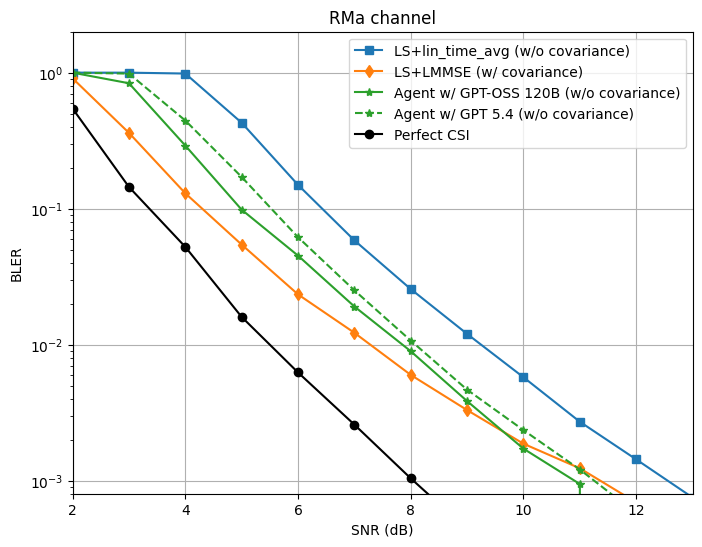

In [4]:
bler_ = BLER["rma"]

# Plot the BLER curves
plt.figure(figsize=(8, 6))
plt.semilogy(bler_["baseline"][0] + 12, bler_["baseline"][1], label='LS+lin_time_avg (w/o covariance)', marker='s', color='C0')
plt.semilogy(bler_["baseline-lmmse"][0] + 12, bler_["baseline-lmmse"][1], label='LS+LMMSE (w/ covariance)', marker='d', linestyle='-', color='C1')
plt.semilogy(bler_["agent-gpt-oss-120b"][0] + 12, bler_["agent-gpt-oss-120b"][1], label='Agent w/ GPT-OSS 120B (w/o covariance)', marker='*', linestyle='-', color='C2')
plt.semilogy(bler_["agent-gpt-5.4"][0] + 12, bler_["agent-gpt-5.4"][1], label='Agent w/ GPT 5.4 (w/o covariance)', marker='*', linestyle='--', color='C2')
plt.semilogy(bler_['perfect-csi'][0] + 12, bler_['perfect-csi'][1], label='Perfect CSI', marker='o', linestyle='-', color='k')
plt.xlabel('SNR (dB)')
plt.ylabel('BLER')
plt.ylim(8e-4, 2)
plt.xlim(2, 13)
plt.legend()
plt.grid(True)
plt.title("RMa channel")
# plt.savefig("bler_rma.png", dpi=150, bbox_inches='tight')